<a href="https://colab.research.google.com/github/harpreetsingh171190-cmyk/crack-detection-app/blob/main/Surface_Crack_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Dataset ready! Analyzing Crack Severity and Structural Risk...
----------------------------------------
Total Area: 51529 pixels
Crack Area: 2370 pixels
Severity Percentage: 4.60%
Condition Level: Medium (Maintenance Needed)
----------------------------------------


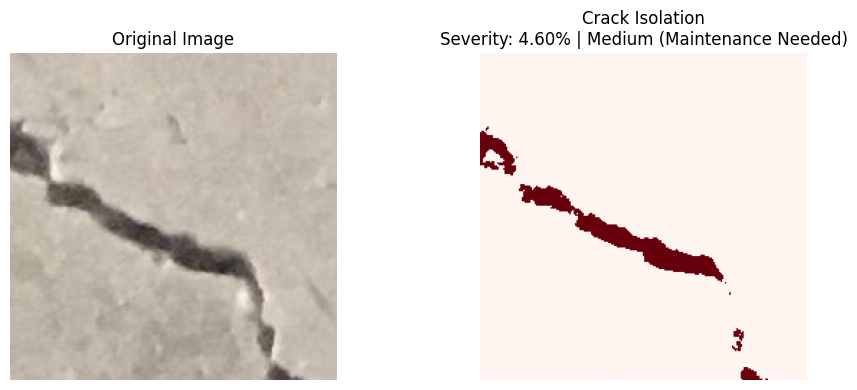

In [ ]:

import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Check and download dataset if Colab disconnected
if not os.path.exists('crack_dataset/Positive'):
    print("⚡ Re-downloading dataset...")
    !mkdir -p ~/.kaggle
    token_text = "KGAT_d9bcfa9cd425b11c978a813ff8322601"
    with open('/root/.kaggle/access_token', 'w') as f:
        f.write(token_text)
    !chmod 600 ~/.kaggle/access_token
    !kaggle datasets download -d arunrk7/surface-crack-detection
    os.makedirs('crack_dataset', exist_ok=True)
    with zipfile.ZipFile('surface-crack-detection.zip', 'r') as zip_ref:
        zip_ref.extractall('crack_dataset')

print("✅ Dataset ready! Analyzing Crack Severity and Structural Risk...")

# 2. Pick a random crack image directly from the folder
positive_folder = 'crack_dataset/Positive'
sample_image_path = os.path.join(positive_folder, os.listdir(positive_folder)[0])

# 3. Read image
img_for_analysis = cv2.imread(sample_image_path)
img_for_analysis = cv2.cvtColor(img_for_analysis, cv2.COLOR_BGR2RGB)
gray_img = cv2.cvtColor(img_for_analysis, cv2.COLOR_RGB2GRAY)

# 4. Apply Binary Thresholding (Isolating the crack)
_, binary_crack = cv2.threshold(gray_img, 100, 255, cv2.THRESH_BINARY_INV)

# 5. Quantify the crack
total_pixels = binary_crack.shape[0] * binary_crack.shape[1]
crack_pixels = np.sum(binary_crack == 255)
severity_percentage = (crack_pixels / total_pixels) * 100

# 6. Determine Severity Level
if severity_percentage == 0:
    level = "No Crack Detected"
elif severity_percentage < 2.0:
    level = "Low (Minor / Safe)"
elif severity_percentage < 5.0:
    level = "Medium (Maintenance Needed)"
else:
    level = "High (Critical Structural Risk)"

# 7. Print Industrial Report
print("-" * 40)
print(f"Total Area: {total_pixels} pixels")
print(f"Crack Area: {crack_pixels} pixels")
print(f"Severity Percentage: {severity_percentage:.2f}%")
print(f"Condition Level: {level}")
print("-" * 40)

# 8. Visualize the Crack Isolation
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_for_analysis)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_crack, cmap='Reds')
plt.title(f"Crack Isolation\nSeverity: {severity_percentage:.2f}% | {level}")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:

import os
import zipfile
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

print("⚡ Setting up Kaggle and Dataset...")
!mkdir -p ~/.kaggle
token_text = "KGAT_d9bcfa9cd425b11c978a813ff8322601"
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(token_text)
!chmod 600 ~/.kaggle/access_token

# Download dataset if not present
if not os.path.exists('surface-crack-detection.zip'):
    !kaggle datasets download -d arunrk7/surface-crack-detection

# Extract dataset
os.makedirs('crack_dataset', exist_ok=True)
with zipfile.ZipFile('surface-crack-detection.zip', 'r') as zip_ref:
    zip_ref.extractall('crack_dataset')

print("🚀 Starting Fast Training...")
dataset_path = 'crack_dataset'
BATCH_SIZE = 64
IMG_SIZE = (64, 64)

train_data = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_data = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Lightweight CNN Model for Fast Execution
model = Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(64, 64, 3)),
    Conv2D(16, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train for 1 Epoch for quick results
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=1
)

# Save the model
model.save('crack_detection_model.h5')
print("\n✅ Model successfully trained and saved as 'crack_detection_model.h5'!")

⚡ Setting up Kaggle and Dataset...
🚀 Starting Fast Training...
Found 40000 files belonging to 2 classes.
Using 32000 files for training.
Found 40000 files belonging to 2 classes.
Using 8000 files for validation.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.9487 - loss: 0.1428 - val_accuracy: 0.9844 - val_loss: 0.0491



✅ Model successfully trained and saved as 'crack_detection_model.h5'!


Generating Industrial Evaluation Metrics...
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


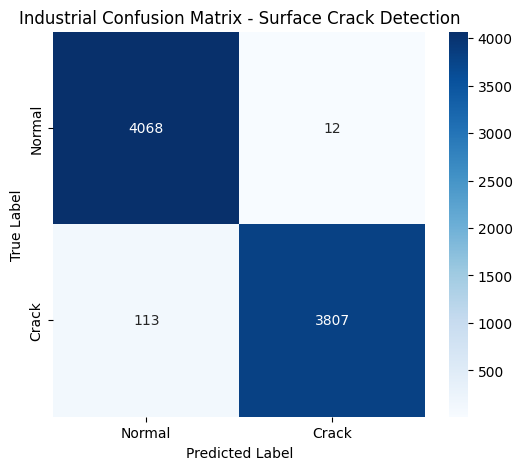


--- Detailed Classification Report ---
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98      4080
       Crack       1.00      0.97      0.98      3920

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000



In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("Generating Industrial Evaluation Metrics...")

# 1. Safely extract all validation images and true labels
val_images = []
val_labels = []

for images, labels in val_data:
    val_images.append(images.numpy())
    val_labels.append(labels.numpy())

val_images = np.concatenate(val_images, axis=0)
val_labels = np.concatenate(val_labels, axis=0)

# 2. Get predictions from our trained model
predictions = model.predict(val_images)
pred_labels = (predictions > 0.5).astype(int)

# 3. Confusion Matrix Calculation & Plotting
cm = confusion_matrix(val_labels, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Crack'], yticklabels=['Normal', 'Crack'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Industrial Confusion Matrix - Surface Crack Detection')
plt.show()

# 4. Print Classification Report
print("\n--- Detailed Classification Report ---")
print(classification_report(val_labels, pred_labels, target_names=['Normal', 'Crack']))

Setting up Explainable AI (Grad-CAM)...


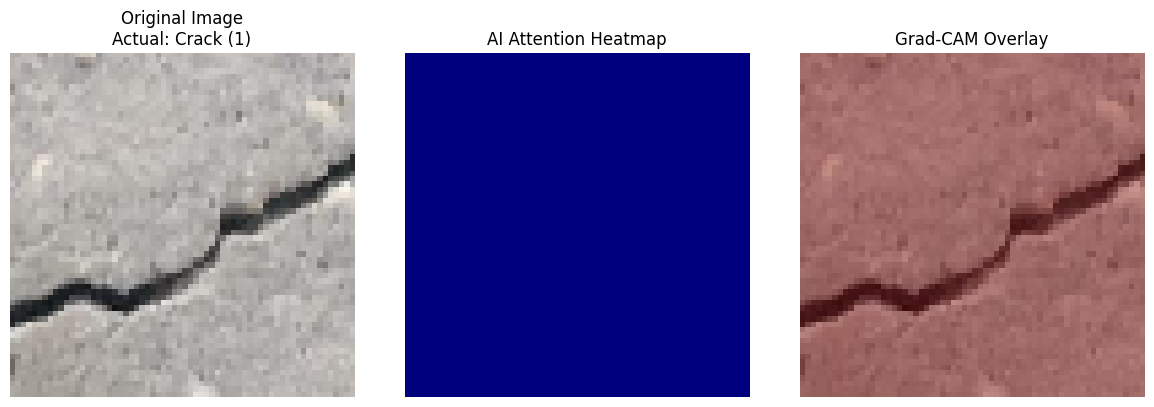

In [ ]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

print("Setting up Explainable AI (Grad-CAM)...")

# 1. Find the last convolutional layer of our model
last_conv_layer_name = None
for layer in model.layers[::-1]:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # FIX: Manually building a Functional model for Keras 3 compatibility
    inputs = tf.keras.Input(shape=(64, 64, 3))
    x = inputs
    last_conv_output = None

    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            last_conv_output = x

    grad_model = tf.keras.Model(inputs=inputs, outputs=[last_conv_output, x])

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    # Adding a small epsilon (1e-10) to avoid division by zero
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# 2. Pick a sample image from validation dataset
sample_images, sample_labels = next(iter(val_data))
img_array = sample_images[0:1] # Taking the first image
actual_label = sample_labels[0].numpy()

# 3. Generate heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# 4. Superimpose heatmap on original image
img = img_array[0].numpy().astype("uint8")
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# Combine the original image with the heatmap
superimposed_img = cv2.addWeighted(img, 0.6, heatmap_colored, 0.4, 0)

# 5. Display the results
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f"Original Image\nActual: {'Crack (1)' if actual_label==1 else 'Normal (0)'}")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap='jet')
plt.title("AI Attention Heatmap")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title("Grad-CAM Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()

Analyzing Crack Severity and Structural Risk...
----------------------------------------
Total Area: 4096 pixels
Crack Area: 228 pixels
Severity Percentage: 5.57%
Condition Level: High (Critical Structural Risk)
----------------------------------------


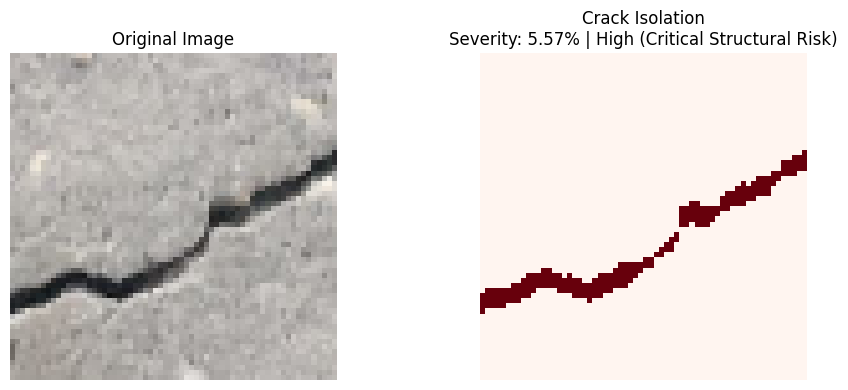

In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Analyzing Crack Severity and Structural Risk...")

# 1. Take the same image used in the Grad-CAM step
img_for_analysis = img_array[0].numpy().astype("uint8")

# 2. Convert to Grayscale
gray_img = cv2.cvtColor(img_for_analysis, cv2.COLOR_RGB2GRAY)

# 3. Apply Binary Thresholding to isolate the crack (darker pixels)
# Using inverse thresholding because cracks are usually darker than the surface
_, binary_crack = cv2.threshold(gray_img, 100, 255, cv2.THRESH_BINARY_INV)

# 4. Quantify the crack
total_pixels = binary_crack.shape[0] * binary_crack.shape[1]
crack_pixels = np.sum(binary_crack == 255)
severity_percentage = (crack_pixels / total_pixels) * 100

# 5. Determine the Severity Level
if severity_percentage == 0:
    level = "No Crack Detected"
elif severity_percentage < 2.0:
    level = "Low (Minor / Safe)"
elif severity_percentage < 5.0:
    level = "Medium (Maintenance Needed)"
else:
    level = "High (Critical Structural Risk)"

print("-" * 40)
print(f"Total Area: {total_pixels} pixels")
print(f"Crack Area: {crack_pixels} pixels")
print(f"Severity Percentage: {severity_percentage:.2f}%")
print(f"Condition Level: {level}")
print("-" * 40)

# 6. Visualize the Crack Isolation
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_for_analysis)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_crack, cmap='Reds')
plt.title(f"Crack Isolation\nSeverity: {severity_percentage:.2f}% | {level}")
plt.axis('off')

plt.tight_layout()
plt.show()

Generating 3D Surface Topology Model...


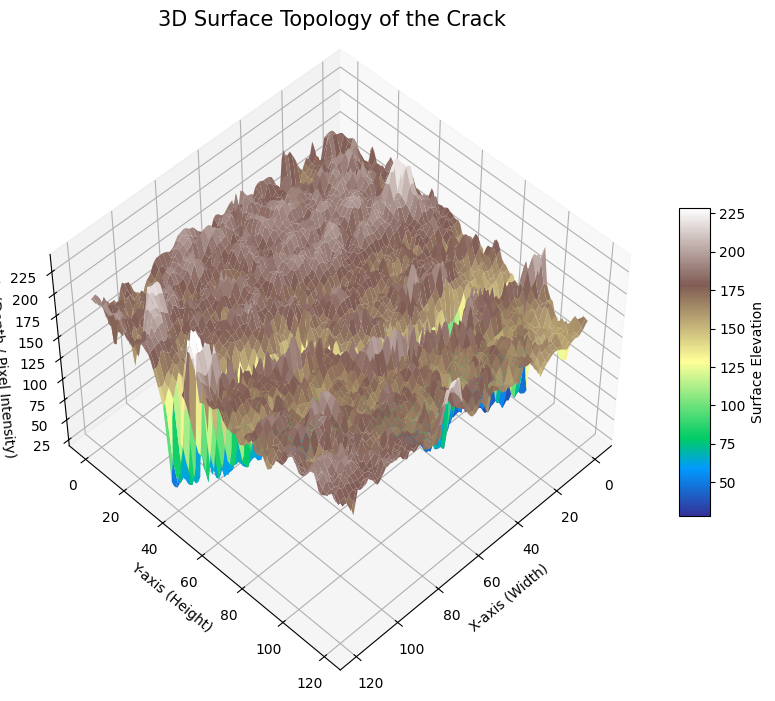

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import cv2

print("Generating 3D Surface Topology Model...")

# 1. Resize the image to speed up 3D plotting and prevent memory overload
small_gray = cv2.resize(gray_img, (120, 120))

# 2. Create X and Y axes (Width and Height)
X = np.arange(0, small_gray.shape[1], 1)
Y = np.arange(0, small_gray.shape[0], 1)
X, Y = np.meshgrid(X, Y)

# 3. Create Z axis (Depth) - using pixel intensity as surface elevation
Z = small_gray

# 4. Plot the 3D Surface Graph
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# The 'terrain' colormap visualizes the structural depth perfectly
surf = ax.plot_surface(X, Y, Z, cmap='terrain', edgecolor='none', rstride=2, cstride=2)

ax.set_title("3D Surface Topology of the Crack", fontsize=15, pad=20)
ax.set_xlabel("X-axis (Width)")
ax.set_ylabel("Y-axis (Height)")
ax.set_zlabel("Z-axis (Depth / Pixel Intensity)")

# Set the viewing angle for the best 3D perspective
ax.view_init(elev=50, azim=45)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="Surface Elevation")
plt.show()

Generating Advanced Statistical and CS Graphs...


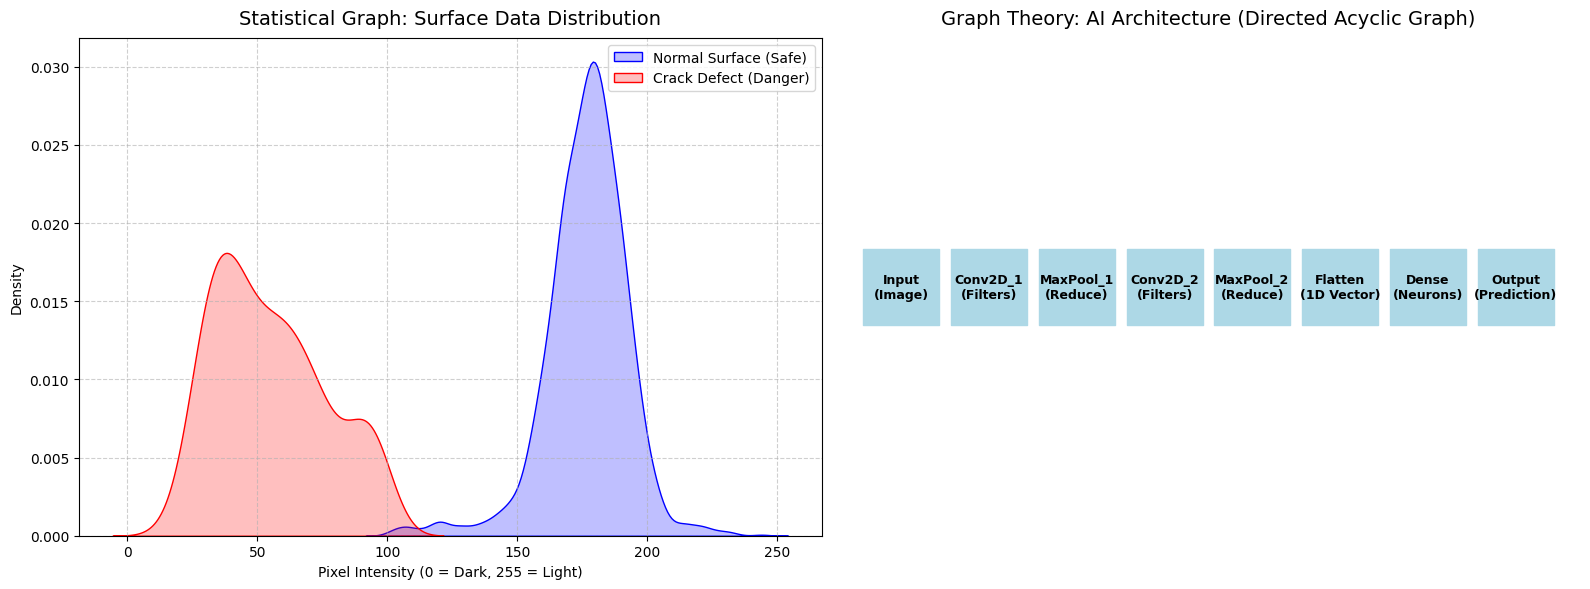

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

print("Generating Advanced Statistical and CS Graphs...")

fig = plt.figure(figsize=(16, 6))

# ---------------------------------------------------------
# 1. Statistical & Data Graph (Pixel Intensity Distribution)
# ---------------------------------------------------------
plt.subplot(1, 2, 1)

# Extracting pixel values for crack vs normal areas based on our previous mask
normal_pixels = gray_img[binary_crack == 0]
crack_pixels = gray_img[binary_crack == 255]

# Plotting Kernel Density Estimation (KDE) to show data distribution
sns.kdeplot(normal_pixels, fill=True, color='blue', label='Normal Surface (Safe)')
sns.kdeplot(crack_pixels, fill=True, color='red', label='Crack Defect (Danger)')

plt.title("Statistical Graph: Surface Data Distribution", fontsize=14, pad=10)
plt.xlabel("Pixel Intensity (0 = Dark, 255 = Light)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# 2. Mathematical & CS Graph Theory (CNN Architecture as DAG)
# ---------------------------------------------------------
plt.subplot(1, 2, 2)

# Creating a Directed Graph using Graph Theory principles
G = nx.DiGraph()

# Defining nodes (Layers of our CNN Model)
layers = [
    'Input\n(Image)',
    'Conv2D_1\n(Filters)',
    'MaxPool_1\n(Reduce)',
    'Conv2D_2\n(Filters)',
    'MaxPool_2\n(Reduce)',
    'Flatten\n(1D Vector)',
    'Dense\n(Neurons)',
    'Output\n(Prediction)'
]

# Adding Edges to connect the Nodes (The flow of data)
for i in range(len(layers)-1):
    G.add_edge(layers[i], layers[i+1])

# Defining positions to lay them out horizontally
pos = {layer: (i, 0) for i, layer in enumerate(layers)}

# Drawing the CS Graph
nx.draw(
    G, pos,
    with_labels=True,
    node_color='lightblue',
    node_size=3000,
    edge_color='gray',
    font_size=9,
    font_weight='bold',
    arrowsize=20,
    node_shape='s' # Square nodes
)

plt.title("Graph Theory: AI Architecture (Directed Acyclic Graph)", fontsize=14, pad=10)

plt.tight_layout()
plt.show()

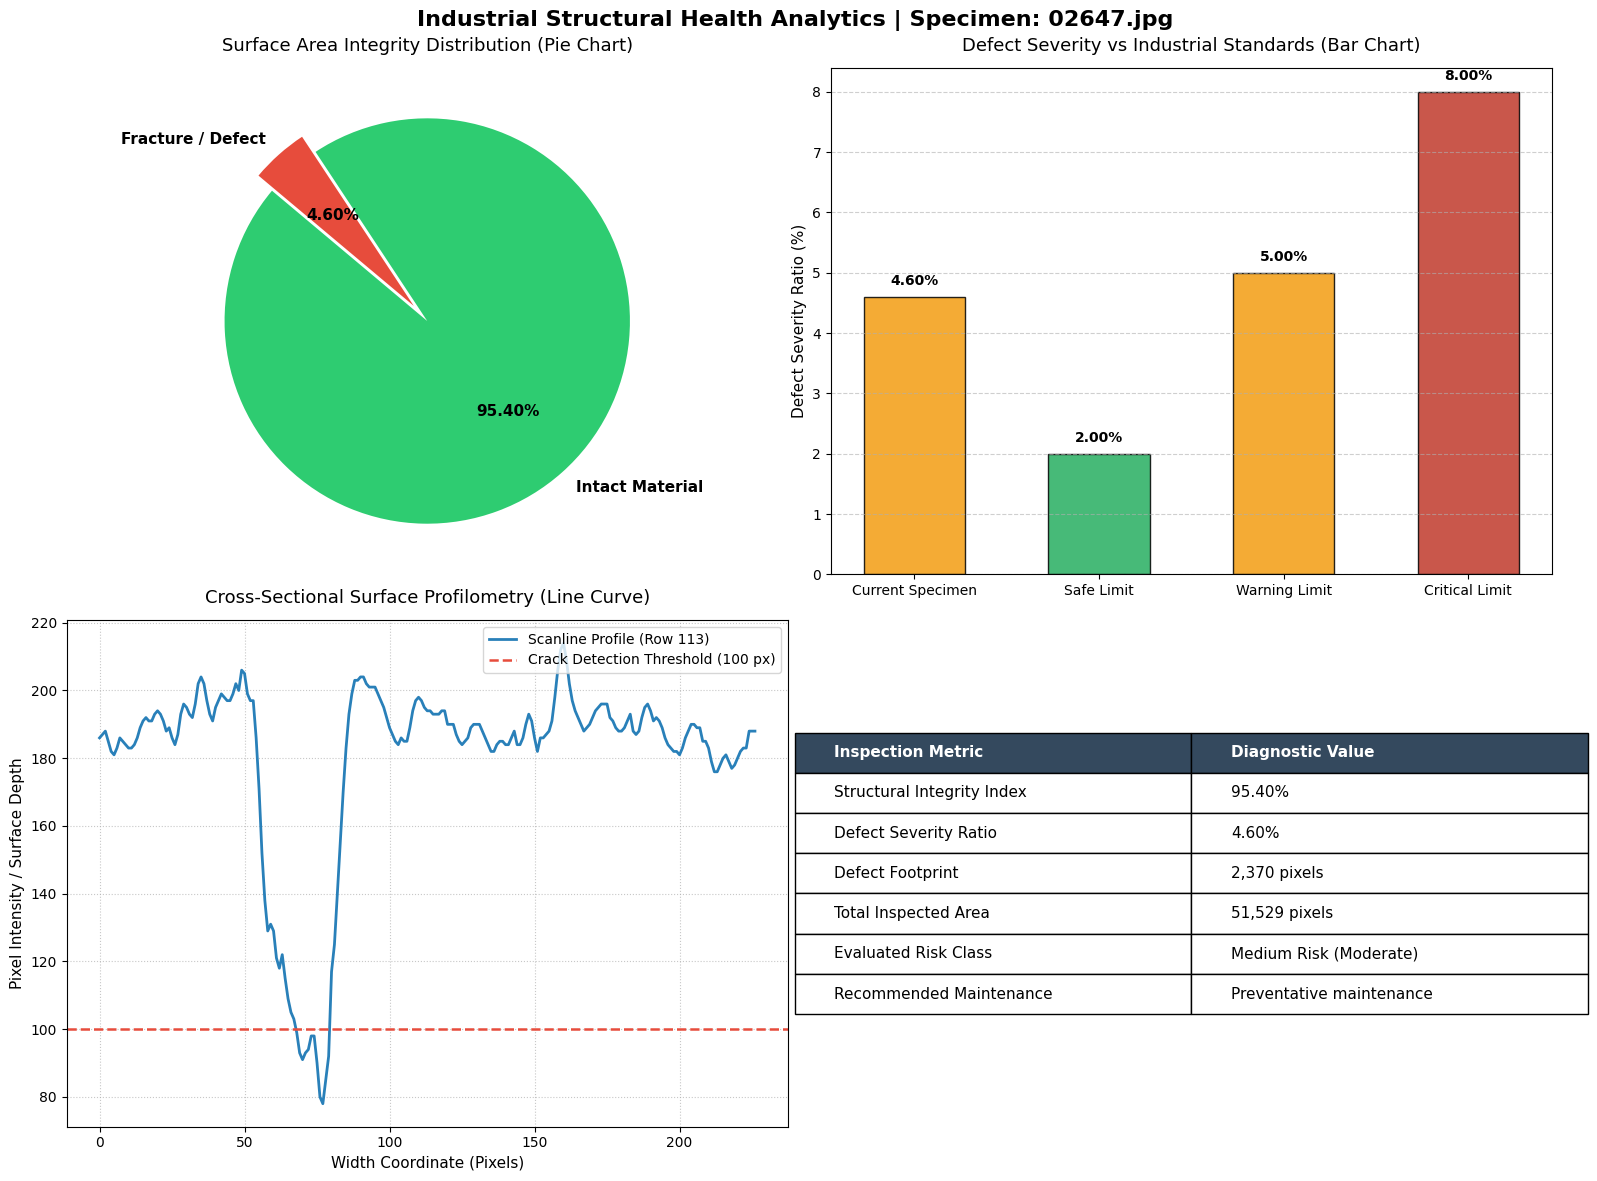

In [ ]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load a sample crack image from dataset
positive_folder = 'crack_dataset/Positive'
sample_image_name = os.listdir(positive_folder)[0]
sample_image_path = os.path.join(positive_folder, sample_image_name)

# 2. Image Processing & Defect Quantification
img_bgr = cv2.imread(sample_image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Binary thresholding for crack isolation
_, binary_crack = cv2.threshold(gray_img, 100, 255, cv2.THRESH_BINARY_INV)

total_pixels = binary_crack.shape[0] * binary_crack.shape[1]
crack_pixels = np.sum(binary_crack == 255)
intact_pixels = total_pixels - crack_pixels
severity_percentage = (crack_pixels / total_pixels) * 100
integrity_score = 100.0 - severity_percentage

# Risk classification logic
if severity_percentage == 0:
    risk_level = "Nominal (No Defect)"
    action = "No intervention required"
elif severity_percentage < 2.0:
    risk_level = "Low Risk (Minor)"
    action = "Routine surveillance"
elif severity_percentage < 5.0:
    risk_level = "Medium Risk (Moderate)"
    action = "Preventative maintenance"
else:
    risk_level = "High Risk (Critical)"
    action = "Immediate structural repair"

# 3. Create Multi-Chart Inspection Dashboard
fig = plt.figure(figsize=(16, 12))
plt.suptitle(f"Industrial Structural Health Analytics | Specimen: {sample_image_name}", fontsize=16, fontweight='bold', y=0.98)

# Chart 1: Pie Chart (Surface Integrity Ratio)
ax1 = plt.subplot(2, 2, 1)
pie_labels = ['Intact Material', 'Fracture / Defect']
pie_sizes = [intact_pixels, max(crack_pixels, 1)]
pie_colors = ['#2ecc71', '#e74c3c']
ax1.pie(pie_sizes, labels=pie_labels, autopct='%1.2f%%', startangle=140, colors=pie_colors, explode=(0, 0.1), textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title("Surface Area Integrity Distribution (Pie Chart)", fontsize=13, pad=12)

# Chart 2: Bar Chart (Industrial Benchmark Comparison)
ax2 = plt.subplot(2, 2, 2)
categories = ['Current Specimen', 'Safe Limit', 'Warning Limit', 'Critical Limit']
values = [severity_percentage, 2.0, 5.0, 8.0]
bar_colors = ['#e74c3c' if severity_percentage > 5 else ('#f39c12' if severity_percentage > 2 else '#2ecc71'), '#27ae60', '#f39c12', '#c0392b']
bars = ax2.bar(categories, values, color=bar_colors, width=0.55, edgecolor='black', alpha=0.85)
ax2.set_ylabel("Defect Severity Ratio (%)", fontsize=11)
ax2.set_title("Defect Severity vs Industrial Standards (Bar Chart)", fontsize=13, pad=12)
ax2.grid(axis='y', linestyle='--', alpha=0.6)
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.15, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

# Chart 3: Line Curve (Profilometry Scanline Trace)
ax3 = plt.subplot(2, 2, 3)
mid_row_idx = gray_img.shape[0] // 2
scanline = gray_img[mid_row_idx, :]
ax3.plot(scanline, color='#2980b9', lw=2, label=f'Scanline Profile (Row {mid_row_idx})')
ax3.axhline(100, color='#e74c3c', linestyle='--', lw=1.8, label='Crack Detection Threshold (100 px)')
ax3.set_xlabel("Width Coordinate (Pixels)", fontsize=11)
ax3.set_ylabel("Pixel Intensity / Surface Depth", fontsize=11)
ax3.set_title("Cross-Sectional Surface Profilometry (Line Curve)", fontsize=13, pad=12)
ax3.legend(loc='upper right')
ax3.grid(True, linestyle=':', alpha=0.7)

# Chart 4: Engineering Inspection Summary Table
ax4 = plt.subplot(2, 2, 4)
ax4.axis('tight')
ax4.axis('off')

table_data = [
    ["Inspection Metric", "Diagnostic Value"],
    ["Structural Integrity Index", f"{integrity_score:.2f}%"],
    ["Defect Severity Ratio", f"{severity_percentage:.2f}%"],
    ["Defect Footprint", f"{crack_pixels:,} pixels"],
    ["Total Inspected Area", f"{total_pixels:,} pixels"],
    ["Evaluated Risk Class", risk_level],
    ["Recommended Maintenance", action]
]

table = ax4.table(cellText=table_data, loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.1, 2.0)

# Format header row
for j in range(2):
    table[(0, j)].set_facecolor('#34495e')
    table[(0, j)].get_text().set_color('white')
    table[(0, j)].get_text().set_weight('bold')

plt.tight_layout()
plt.show()

In [ ]:

!pkill -9 -f streamlit || true

import subprocess
import time

process = subprocess.Popen([
    "python", "-m", "streamlit",
    "run", "app.py",
    "--server.port=8501",
    "--server.headless=true"
])

time.sleep(5)

print("✅ Streamlit started")

^C
✅ Streamlit started


In [ ]:
!curl -I http://127.0.0.1:8501

HTTP/1.1 200 OK
date: Sun, 06 Sep 2026 10:21:56 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 7459
last-modified: Sun, 06 Sep 2026 10:03:12 GMT
etag: "9b671a5e4480cdc17b4a6b8620908e1f"
cache-control: no-cache



In [ ]:

import os
import subprocess
import time
from pyngrok import ngrok

# 1. Create the Streamlit config directory and file programmatically
os.makedirs(".streamlit", exist_ok=True)
config_content = """
[server]
maxUploadSize = 200
headless = true
enableCORS = false
enableXsrfProtection = false
"""
with open(".streamlit/config.toml", "w") as f:
    f.write(config_content.strip())

# 2. Automatically find your project's python file
py_files = [f for f in os.listdir('.') if f.endswith('.py')]
app_file = "app.py"
if app_file not in py_files:
    for f in py_files:
        if "crack" in f.lower() or "app" in f.lower() or "main" in f.lower():
            app_file = f
            break
    else:
        if py_files:
            app_file = py_files[0]

print(f"Target application script: {app_file}")

# 3. Terminate any previous instances
!fuser -k 8501/tcp
!pkill -9 -f streamlit
ngrok.kill()

# 4. Set your Ngrok authentication token
NGROK_AUTH_TOKEN = "3IwffPd7Kd9LUxfihuhvuMNeLV5_3cmKi5itbHbmqwf2dF4bo"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# 5. Start the Streamlit server
print("Starting Streamlit server with increased upload size...")
streamlit_process = subprocess.Popen(
    ["python", "-m", "streamlit", "run", app_file, "--server.port", "8501"],
    stdout=open("streamlit.log", "w"),
    stderr=subprocess.STDOUT
)

# Wait 5 seconds for the server to fully initialize
time.sleep(5)

# 6. Establish the Ngrok tunnel
tunnel = ngrok.connect(addr="127.0.0.1:8501", proto="http")
public_url = tunnel.public_url

print("\n" + "=" * 60)
print("👉 SECURE NGROK URL (CLICK TO OPEN):")
print(public_url)
print("=" * 60 + "\n")

Target application script: app.py
8501/tcp:             9107
Starting Streamlit server with increased upload size...

👉 SECURE NGROK URL (CLICK TO OPEN):
https://plow-sublevel-excavator.ngrok-free.dev



In [ ]:

# 1. Save the model
model.save('crack_detection_model.h5')

# 2. Download the model file
from google.colab import files
files.download('crack_detection_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>